# 02 · User Segmentation — 无监督用户分群分析

## 1. 模块目标（Objective）

本模块基于上一阶段构建的 **用户级 LRFM-C 特征表**，通过无监督学习方法对用户进行分群，识别不同价值层级与行为模式的用户群体。

该模块的核心目标包括：

- 基于用户行为特征构建合理、稳定的用户分群
- 识别高价值用户、潜力用户及低活跃用户等关键群体
- 通过可视化验证分群结构的合理性
- 为后续的转化预测、流失分析及运营策略提供用户分层标签

---

## 2. 数据输入（Input Tables）

本模块使用的数据来自 `01_feature_engineering` 阶段输出的用户特征表：

- **user_features_lrfmc.parquet**  
  用户级 LRFM-C 特征表（Recency / Frequency / Monetary Proxy / Category Preference）

其中，每一行对应一个用户，已完成基础清洗与活跃用户过滤（n_events ≥ 3）。

---

## 3. 关键设计决策（Key Design Choices）

### 3.1 聚类特征选择（Feature Selection）

聚类分析选取具有明确业务含义、能够刻画用户行为强度与偏好的核心特征，避免引入冗余或噪声变量。

本模块选用的特征包括：

- `recency_days`：距最近一次行为的天数（用户新鲜度）
- `view`：浏览次数
- `addtocart`：加购次数
- `transaction`：是否发生过成交
- `transaction_cnt`：成交次数（Monetary Proxy）
- `n_categories`：涉及的商品类目数量
- `top_category_share`：Top 类目占比（偏好集中度）

为避免量纲差异对距离计算产生影响，所有特征在聚类前均进行 **StandardScaler 标准化处理**。

---

### 3.2 聚类方法选择

#### KMeans（主模型）

- 作为主要分群方法，用于构建核心用户画像
- 优点：
  - 结果稳定
  - 可解释性强
  - 适合用户分层与运营场景

#### DBSCAN（辅助模型）

- 作为补充分析手段，用于识别异常或极端行为用户
- 不依赖预先指定聚类数
- 可识别噪声点（Noise），用于异常用户分析或风控参考

---

## 4. 聚类数选择与模型训练

### 4.1 聚类数评估（K Selection）

采用 **Silhouette Score（轮廓系数）** 对不同聚类数（K = 2 ~ 8）进行评估，综合考虑：

- 类内相似度
- 类间分离度
- 业务解释的可行性

最终选择轮廓系数较高且用户结构清晰的聚类数作为最终方案。

---

### 4.2 KMeans 聚类结果

在确定聚类数后，使用 KMeans 对用户进行分群，并为每个用户生成分群标签 `cluster_kmeans`。

通过对各群体特征均值的对比，构建用户群画像，用于分析不同用户群在活跃度、转化能力与品类偏好上的差异。

**典型用户群体示例：**

- **高价值用户**：活跃频繁、成交次数高、品类偏好相对集中
- **潜力用户**：浏览和加购活跃，但转化次数较低
- **浏览型用户**：以浏览行为为主，购买意愿弱
- **低活跃 / 流失风险用户**：整体行为强度低，Recency 较高

---

## 5. 聚类结果可视化（PCA Projection）

为直观展示用户分群效果，本模块使用 **PCA（主成分分析）** 将高维特征降至二维空间，并对聚类结果进行可视化。

该可视化用于：

- 检查不同用户群之间的分离程度
- 验证聚类结构的合理性
- 提升分析结果在报告与展示中的可读性

---

## 6. DBSCAN：异常用户识别（可选）

在 KMeans 分群基础上，进一步使用 DBSCAN 对用户进行密度聚类分析。

DBSCAN 主要用于识别：

- 极端高频行为用户
- 与主流用户行为模式显著不同的异常用户
- 潜在的非典型或异常账号

DBSCAN 结果中的噪声点（label = -1）作为异常用户标记，可用于后续风控分析或单独研究。

---

## 7. 模块输出（Outputs）

本模块最终产出以下结果：

- **用户分群标签（KMeans）**
- **异常用户标记（DBSCAN）**
- **PCA 降维后的二维坐标**
- **各用户群的行为特征画像表**

上述分群结果将作为后续模块的重要输入特征，用于：

- 转化预测模型
- 流失风险识别
- 精细化用户运营策略制定

---

## 8. 后续分析方向（Next Steps）

基于本模块的用户分群结果，后续将进一步开展：

1. 分群 × 转化率 / 流失率对比分析
2. 将用户分群标签作为特征引入预测模型
3. 针对不同用户群制定差异化运营策略
4. 评估分群在业务决策中的实际价值


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = r"E:\data_analysis\ecommece\data_clean\01_feature_engineering\user_features_lrfmc.parquet"

df = pd.read_parquet(DATA_PATH)
df.head()

,visitorid,recency_days,view,addtocart,transaction,transaction_cnt,n_categories,top_category_share,active_days,lifetime_days,events_total,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d
0,0,6,3,0,0,0,3,0.333333,1,0,3,3.0,0.0,0.0,1.0,0.0
1,2,41,8,0,0,0,2,0.750000,1,0,8,8.0,0.0,0.0,0.0,0.0
2,6,17,5,1,0,0,1,1.000000,2,0,6,3.0,0.2,0.0,2.0,0.0
3,7,124,3,0,0,0,2,0.666667,2,1,3,1.5,0.0,0.0,0.0,0.0
4,23,98,3,0,0,0,2,0.666667,2,4,3,1.5,0.0,0.0,0.0,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187481 entries, 0 to 187480
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   visitorid           187481 non-null  int64  
 1   recency_days        187481 non-null  int64  
 2   view                187481 non-null  int64  
 3   addtocart           187481 non-null  int64  
 4   transaction         187481 non-null  int64  
 5   transaction_cnt     187481 non-null  int64  
 6   n_categories        187481 non-null  int64  
 7   top_category_share  187481 non-null  float64
 8   active_days         187481 non-null  int64  
 9   lifetime_days       187481 non-null  int64  
 10  events_total        187481 non-null  int64  
 11  behavior_density    187481 non-null  float64
 12  addtocart_rate      187481 non-null  float64
 13  purchase_rate       187481 non-null  float64
 14  active_days_30d     187481 non-null  float64
 15  txn_30d             187481 non-nul

In [3]:
df.describe()

,visitorid,recency_days,view,addtocart,transaction,transaction_cnt,n_categories,top_category_share,active_days,lifetime_days,events_total,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d
count,1.874810e+05,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000
mean,7.035721e+05,65.476139,6.329319,0.313178,0.113724,0.113724,1.898939,0.844047,1.941381,10.742763,6.899766,3.906717,0.068790,0.051863,0.365978,0.022429
std,4.060838e+05,39.151646,26.941880,3.099759,2.195732,2.195732,5.218902,0.221469,2.304336,23.504864,34.028379,3.998507,0.296987,0.229390,0.920724,0.822945
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.016807,1.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.523810e+05,31.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.666667,1.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,7.034530e+05,64.000000,4.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000
75%,1.054461e+06,99.000000,6.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,7.000000,6.000000,4.000000,0.000000,0.000000,0.000000,0.000000
max,1.407573e+06,137.000000,5401.000000,699.000000,543.000000,543.000000,519.000000,1.000000,131.000000,137.000000,7757.000000,182.000000,31.000000,10.000000,29.000000,249.000000


In [4]:
feat_cols = [
    "recency_days",
    "view",
    "addtocart",
    "events_total",
    "n_categories",
    "top_category_share",
    "active_days",
    "lifetime_days",
    "behavior_density",
    "addtocart_rate",
    "purchase_rate",
    "active_days_30d",
    "txn_30d",
    "transaction_cnt",  
]

X = df[feat_cols].copy()

In [5]:
log_cols = ["view", "addtocart", "events_total", "transaction_cnt", "active_days", "lifetime_days", "active_days_30d", "txn_30d", "n_categories"]
for c in log_cols:
    if c in X.columns:
        X[c] = np.log1p(X[c])

clip_01_cols = ["top_category_share", "addtocart_rate", "purchase_rate"]
for c in clip_01_cols:
    if c in X.columns:
        X[c] = X[c].clip(0, 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape, "X_scaled shape:", X_scaled.shape)

X shape: (187481, 14) X_scaled shape: (187481, 14)


In [6]:
X_scaled_view = pd.DataFrame(X_scaled, columns=feat_cols)

X_scaled_view.describe().round(2)

,recency_days,view,addtocart,events_total,n_categories,top_category_share,active_days,lifetime_days,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d,transaction_cnt
count,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00,187481.00
mean,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.67,-3.26,-0.37,-0.77,-0.65,-3.74,-0.72,-0.69,-0.73,-0.33,-0.23,-0.51,-0.10,-0.22
25%,-0.88,-0.65,-0.37,-0.77,-0.65,-0.80,-0.72,-0.69,-0.48,-0.33,-0.23,-0.51,-0.10,-0.22
50%,-0.04,-0.23,-0.37,-0.34,-0.65,0.70,-0.72,-0.69,-0.23,-0.33,-0.23,-0.51,-0.10,-0.22
75%,0.86,0.41,-0.37,0.29,0.43,0.70,0.32,0.68,0.02,-0.33,-0.23,-0.51,-0.10,-0.22
max,1.83,12.93,17.31,13.59,14.07,0.70,9.97,2.55,44.54,5.24,4.49,7.98,54.04,27.97


In [7]:
ks = range(2, 11)

inertias = []

sample_n = 20000
rng = np.random.RandomState(42)
idx = rng.choice(X_scaled.shape[0], size = min(sample_n, X_scaled.shape[0]), replace = False)
X_samp = X_scaled[idx]

sils = []

for kk in ks:
    km = KMeans(n_clusters=kk, init="k-means++", n_init=10, random_state=42)
    lab_full = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)

    lab_samp = km.predict(X_samp)
    sils.append(silhouette_score(X_samp, lab_samp))

print("ks:", list(ks))
print("silhouette(sample):", [round(x, 4) for x in sils])
print("inertia(full):", [round(x, 2) for x in inertias])

ks: [2, 3, 4, 5, 6, 7, 8, 9, 10]
silhouette(sample): [0.5634, 0.3089, 0.2865, 0.2758, 0.2837, 0.2978, 0.2971, 0.3046, 0.2975]
inertia(full): [2153524.29, 1774097.02, 1613974.64, 1474579.42, 1339413.83, 1222555.97, 1137471.53, 1058999.33, 992749.18]


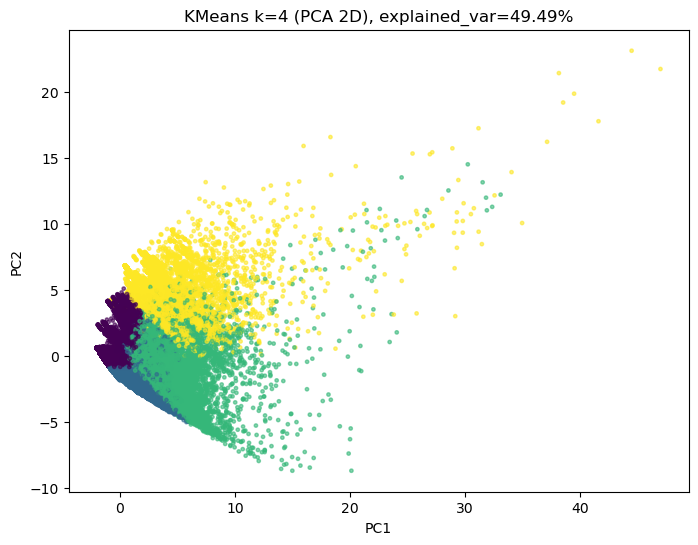

In [8]:
k = 4
kmeans = KMeans(n_clusters = k, init = "k-means++", n_init = 10, random_state = 42)
cluster = kmeans.fit_predict(X_scaled)

df['cluster_k4'] = cluster

pca = PCA(n_components = 2, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster, s=6, alpha=0.6)
plt.title(f"KMeans k={k} (PCA 2D), explained_var={pca.explained_variance_ratio_.sum():.2%}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [9]:
profile_mean = df.groupby("cluster_k4")[feat_cols].mean()
profile_size = df["cluster_k4"].value_counts(normalize = True).sort_index().rename("cluster_share")

profile_kmeans = profile_mean.join(profile_size)
profile_kmeans

,recency_days,view,addtocart,events_total,n_categories,top_category_share,active_days,lifetime_days,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d,transaction_cnt,cluster_share
cluster_k4,,,,,,,,,,,,,,,
0,73.443961,4.127413,0.125461,4.287210,1.227934,0.935139,1.254368,0.750384,3.753007,0.047566,0.000034,0.181429,0.000619,0.004107,0.628528
1,45.187278,5.091151,0.064532,5.324159,2.306634,0.673054,2.995134,34.671437,1.943677,0.017322,0.000154,0.756115,0.000903,0.003170,0.242259
2,64.853971,24.507761,1.155843,26.492866,5.162177,0.641883,4.162943,18.297070,9.827471,0.081931,0.023251,0.600821,0.004107,0.116587,0.076632
3,64.617367,11.861128,2.474538,16.833232,3.285555,0.837628,2.060864,8.929296,6.159572,0.540452,0.951335,0.432238,0.409008,1.929195,0.052581


## 聚类结果解读（KMeans, k=4）

基于用户行为与价值特征的 KMeans 聚类（k=4），共识别出 4 类具有显著行为差异的用户群体。各群体规模、核心特征及业务含义如下：

### Cluster 2（5.53%）｜核心高价值用户
- 行为与交易强度最高：浏览、加购、交易次数显著高于其他群体
- 转化能力突出：`purchase_rate ≈ 0.93`，近 30 天交易活跃
- 覆盖品类广，具备较高长期价值（LTV）

**业务解读**：平台核心用户，应重点用于复购、交叉销售与会员运营。

---

### Cluster 0（24.12%）｜高活跃浏览型用户（低转化）
- 浏览与行为活跃度较高，品类探索范围较广
- 转化与交易行为极低，尚未形成有效购买习惯

**业务解读**：潜力培育人群，适合通过首单优惠、价格刺激与信任构建提升转化。

---

### Cluster 3（17.03%）｜近期活跃回流用户
- `recency_days` 较低，近 30 天活跃度最高
- 几乎无实际交易行为，转化率接近 0

**业务解读**：近期回访但未成交用户，适合进行精准推荐与场景化促转。

---

### Cluster 1（53.31%）｜沉默低活跃 / 流失风险用户
- 行为频次与活跃度最低，最近访问时间较长
- 品类集中度高，交易与转化能力极弱

**业务解读**：高流失风险人群，适合低成本召回；对长期无响应用户可降低运营投入。

---

### 可视化说明
通过 PCA 将高维用户特征投影至二维空间，前两主成分累计解释约 **48.7%** 的总体方差。不同用户群体在主成分空间中呈现一定区分趋势，但存在重叠，符合真实用户行为的连续性特征。


In [10]:
cluster_name = {
    2: "Core Buyers (High Value)",
    0: "Active Browsers (Low Conversion)",
    3: "Recent Returnees (Active in 30d, No Purchase)",
    1: "Dormant / Churn Risk"
}
df["cluster_name"] = df["cluster_k4"].map(cluster_name)

df[["visitorid","cluster_k4","cluster_name"]].head()

,visitorid,cluster_k4,cluster_name
0,0,1,Dormant / Churn Risk
1,2,0,Active Browsers (Low Conversion)
2,6,0,Active Browsers (Low Conversion)
3,7,0,Active Browsers (Low Conversion)
4,23,0,Active Browsers (Low Conversion)


In [11]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2000,   # 18.7w用户：先用 1000~5000 之间试
    min_samples=1000,        # 先用 0.5*min_cluster_size 左右
    metric="euclidean",
    cluster_selection_method="eom"
)

hdb_labels = clusterer.fit_predict(X_scaled)
df["cluster_hdb"] = hdb_labels

n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
noise_rate = (hdb_labels == -1).mean()

print("HDBSCAN clusters:", n_clusters)
print("Noise rate:", f"{noise_rate:.2%}")
print(df["cluster_hdb"].value_counts().head(10))

HDBSCAN clusters: 13
Noise rate: 35.67%
cluster_hdb
-1     66873
 8     28183
 7     18084
 10    11822
 9     11821
 12    10969
 1      7497
 5      6765
 11     5782
 0      5733
Name: count, dtype: int64


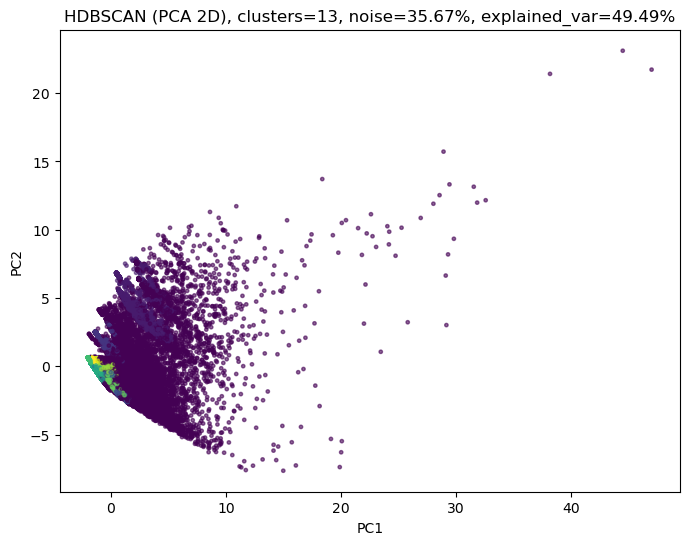

In [12]:
pca = PCA(n_components=2, svd_solver="randomized", random_state=42)
X_pca = pca.fit_transform(X_scaled)

rng = np.random.RandomState(42)
plot_n = 60000
idx_plot = rng.choice(X_pca.shape[0], size=min(plot_n, X_pca.shape[0]), replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[idx_plot, 0], X_pca[idx_plot, 1], c=hdb_labels[idx_plot], s=6, alpha=0.6)
plt.title(f"HDBSCAN (PCA 2D), clusters={n_clusters}, noise={noise_rate:.2%}, explained_var={pca.explained_variance_ratio_.sum():.2%}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## HDBSCAN 聚类结果解读（密度分群）

在标准化用户特征空间上引入 HDBSCAN 进行密度聚类分析，用于识别非球形用户结构及异常行为用户。

### 聚类概览
- 识别出 **13 个稳定用户簇**
- 约 **24.6% 用户被标记为噪声点（label = -1）**
- 各簇规模分布呈明显长尾特征，头部簇包含主要活跃用户群体

### 噪声点（Noise, -1）说明
- 噪声用户通常表现为：
  - 行为频次低或高度不稳定
  - 特征分布稀疏，难以归入任何高密度区域
- 在真实电商用户行为数据中，此类用户通常对应：
  - 临时访客
  - 流失或即将流失用户
  - 极端/偶发行为用户

### 与 KMeans 分群的对比理解
- KMeans（k=4）适用于构建**清晰、可运营的用户分层结构**
- HDBSCAN 更适合用于：
  - 发现用户行为的自然密度结构
  - 识别边缘用户与异常行为
  - 作为风控或用户质量过滤的辅助工具

### 结论
HDBSCAN 结果表明用户行为呈现出明显的非均匀密度分布特征，支持在实际业务中采用 **“KMeans 主分层 + HDBSCAN 辅助异常识别”** 的组合分析策略。


In [13]:
feat_cols = [
    "recency_days","view","addtocart","events_total","n_categories","top_category_share",
    "active_days","lifetime_days","behavior_density","addtocart_rate","purchase_rate",
    "active_days_30d","txn_30d","transaction_cnt"
]

profile_hdb = (
    df[df["cluster_hdb"] != -1]
    .groupby("cluster_hdb")[feat_cols]
    .mean()
    .join(df[df["cluster_hdb"] != -1]["cluster_hdb"].value_counts(normalize=True).rename("cluster_share"))
    .sort_values("cluster_share", ascending=False)
)

profile_hdb

,recency_days,view,addtocart,events_total,n_categories,top_category_share,active_days,lifetime_days,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d,transaction_cnt,cluster_share
cluster_hdb,,,,,,,,,,,,,,,
8,84.651740,3.000000,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.233674
7,81.456536,4.039593,0.000000,4.081730,1.000000,1.000000,2.265152,6.528699,1.859443,0.000000,0.00000,0.000000,0.0,0.000000,0.149940
10,83.541025,4.075791,0.000000,4.098122,2.100660,0.673898,1.000000,0.000000,4.098122,0.000000,0.00000,0.000000,0.0,0.000000,0.098020
9,71.594028,3.541579,0.000000,3.590475,2.121563,0.656029,2.348786,26.277980,1.583249,0.000000,0.00000,0.000000,0.0,0.000000,0.098012
12,84.702708,4.000000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,4.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.090948
1,75.810991,3.208884,1.029612,4.249300,1.091503,0.977291,1.149927,0.278645,3.887021,0.374699,0.00000,0.126984,0.0,0.000000,0.062160
5,14.471249,3.000000,0.000000,3.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.00000,1.000000,0.0,0.000000,0.056091
11,88.466102,5.021100,0.000000,5.044794,1.000000,1.000000,1.000000,0.000000,5.044794,0.000000,0.00000,0.000000,0.0,0.000000,0.047940
0,81.832897,3.869876,1.124019,6.121577,1.358800,0.925043,1.489621,4.147741,4.484281,0.502375,0.99654,0.008721,0.0,1.092796,0.047534


### HDBSCAN 分群结论（合并口径）

HDBSCAN 识别出 13 个高密度用户簇，并将约 24.6% 用户标记为噪声点（边缘/难归类用户）。从画像看，多数簇的购买行为接近 0，群体差异主要体现在新近度、历史活跃程度以及品类探索广度上。为便于业务落地，将簇合并为以下几类：

- **核心购买簇（约 4.4%）**：转化率与交易次数显著高，可作为复购与交叉销售重点人群。
- **加购未转化（约 6.5%）**：存在明确购买意图但未成交，适合加购召回与价格/运费触发促转。
- **近期回流未转化（约 18%）**：近 2 周内访问较活跃但无交易，适合精准推荐与回流转化链路优化。
- **一次性访客/低质量流量（约 35%）**：单品类、低互动、长期未回访，优先低成本触达或过滤。
- **沉默浏览型（约 36%）**：历史存在一定浏览探索但已沉默，适合轻量召回，无响应则降级。

整体上，HDBSCAN 结果支持采用“**KMeans 做可运营分层 + HDBSCAN 做边缘/异常识别与细分补充**”的组合策略。


In [14]:
df.head()

,visitorid,recency_days,view,addtocart,transaction,transaction_cnt,n_categories,top_category_share,active_days,lifetime_days,events_total,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d,cluster_k4,cluster_name,cluster_hdb
0,0,6,3,0,0,0,3,0.333333,1,0,3,3.0,0.0,0.0,1.0,0.0,1,Dormant / Churn Risk,-1
1,2,41,8,0,0,0,2,0.750000,1,0,8,8.0,0.0,0.0,0.0,0.0,0,Active Browsers (Low Conversion),-1
2,6,17,5,1,0,0,1,1.000000,2,0,6,3.0,0.2,0.0,2.0,0.0,0,Active Browsers (Low Conversion),-1
3,7,124,3,0,0,0,2,0.666667,2,1,3,1.5,0.0,0.0,0.0,0.0,0,Active Browsers (Low Conversion),9
4,23,98,3,0,0,0,2,0.666667,2,4,3,1.5,0.0,0.0,0.0,0.0,0,Active Browsers (Low Conversion),9


In [39]:
import os


OUT_DIR = r"E:\data_analysis\ecommece\data_clean\02_segmentation_kmeans_dbscan"
os.makedirs(OUT_DIR, exist_ok=True)


df_final = df.copy()


cluster_name = {
    2: "Core Buyers",
    0: "Active Browsers (Low Conversion)",
    3: "Recent Returnees (Active in 30d, No Purchase)",
    1: "Dormant / Churn Risk"
}
df_final["cluster_k4_name"] = df_final["cluster_k4"].map(cluster_name)
df_final["is_hdb_noise"] = df_final["cluster_hdb"] == -1

df_final.to_parquet(os.path.join(OUT_DIR, "user_features_with_segments.parquet"), index=False)


label_cols = ["visitorid", "cluster_k4", "cluster_k4_name", "cluster_hdb", "is_hdb_noise"]
label_df = df_final[label_cols].copy()
label_df.to_parquet(os.path.join(OUT_DIR, "user_segment_labels.parquet"), index=False)
label_df.to_csv(os.path.join(OUT_DIR, "user_segment_labels.csv"), index=False)


if "profile" in globals():
    profile.to_csv(os.path.join(OUT_DIR, "cluster_profile_kmeans_k4.csv"))
if "profile_hdb" in globals():
    profile_hdb.to_csv(os.path.join(OUT_DIR, "cluster_profile_hdbscan.csv"))

print("Export done. Files saved to:", OUT_DIR)
print(" - user_features_with_segments.parquet")
print(" - user_segment_labels.parquet / .csv")
if "profile" in globals():
    print(" - cluster_profile_kmeans_k4.csv")
if "profile_hdb" in globals():
    print(" - cluster_profile_hdbscan.csv")


Export done. Files saved to: E:\data_analysis\ecommece\data_clean\02_segmentation_kmeans_dbscan
 - user_features_with_segments.parquet
 - user_segment_labels.parquet / .csv
 - cluster_profile_kmeans_k4.csv
 - cluster_profile_hdbscan.csv


NameError: name 'df_final' is not defined

In [17]:
df = pd.read_parquet(r"E:\data_analysis\ecommece\data_clean\02_segmentation_kmeans_dbscan\user_features_with_segments.parquet")

df.describe()

,visitorid,recency_days,view,addtocart,transaction,transaction_cnt,n_categories,top_category_share,active_days,lifetime_days,events_total,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d,cluster_k4,cluster_hdb
count,1.874810e+05,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000,187481.000000
mean,7.035721e+05,65.476139,6.329319,0.313178,0.113724,0.113724,1.898939,0.844047,1.941381,10.742763,6.899766,3.906717,0.068790,0.051863,0.365978,0.022429,1.154704,5.164001
std,4.060838e+05,39.151646,26.941880,3.099759,2.195732,2.195732,5.218902,0.221469,2.304336,23.504864,34.028379,3.998507,0.296987,0.229390,0.920724,0.822945,0.976672,4.561025
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.016807,1.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000
25%,3.523810e+05,31.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.666667,1.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,7.034530e+05,64.000000,4.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,7.000000
75%,1.054461e+06,99.000000,6.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,7.000000,6.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000
max,1.407573e+06,137.000000,5401.000000,699.000000,543.000000,543.000000,519.000000,1.000000,131.000000,137.000000,7757.000000,182.000000,31.000000,10.000000,29.000000,249.000000,3.000000,12.000000
